# Experiment 4: Sequence Analysis and Irrigation Need Classification

**Roll no.:** 16014324022  
**Dataset:** `irrigation_prediction.csv` (10,000 field records)  
**Reference:** `EXP4 DS.pdf` for the activity/questions and `DS_EXP4.ipynb` for the numbered, code-plus-inference notebook layout.

The handout asks for timestamped robotic sensor data and a failure label. This CSV contains **neither a timestamp nor a vibration measurement nor a failure label**. Following the agreed adaptation, this notebook uses **CSV row order as an illustrative sequence** and classifies the supplied `Irrigation_Need` labels. Row order is not elapsed time; the plots and rolling statistics cannot establish temporal trends, and classification of irrigation need is **not equipment failure prediction**. No timestamps or fault outcomes are invented.


## 1–4. Import, load, check time fields, and inspect missing values

The original row order is kept because there is no timestamp to parse or sort. The sequence index below is only the row number in this file.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv('irrigation_prediction.csv')
df.insert(0, 'Observation_Order', np.arange(1, len(df) + 1))
print('Shape:', df.shape, '(including illustrative row index)')
print('Timestamp column present:', any('date' in c.lower() or 'time' in c.lower() for c in df.columns if c != 'Irrigation_Type'))
print('Failure column present:', any('fail' in c.lower() or 'fault' in c.lower() for c in df.columns))
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate records:', int(df.drop(columns='Observation_Order').duplicated().sum()))
print('Irrigation_Need counts:')
print(df['Irrigation_Need'].value_counts().to_string())
print('\nFirst five rows:')
print(df.head().to_string(index=False))


Shape: (10000, 21) (including illustrative row index)
Timestamp column present: False
Failure column present: False
Missing values: 0
Duplicate records: 0
Irrigation_Need counts:
Irrigation_Need
Low       5864
Medium    3800
High       336

First five rows:
 Observation_Order Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh Crop_Type Crop_Growth_Stage Season Irrigation_Type Water_Source  Field_Area_hectare Mulching_Used  Previous_Irrigation_mm  Region Irrigation_Need
                 1      Clay     6.14          36.48            0.42                     2.17          21.90     31.19      1167.70            4.01            1.97     Wheat        Vegetative   Rabi         Rainfed    Reservoir                4.73           Yes                    1.98   South             Low
                 2      Silt     6.41          50.56            0.38                     0.23          36.50     26.01    

**Inference:** The file has field measurements and conditions rather than machine telemetry. Each record may describe a different field, crop, or region, so adjacent rows must not be treated as consecutive readings from one sensor.


## 5–6. Plot measurements against row order

These plots inspect the stored ordering only. The different units make raw amplitudes unsuitable for comparing variation; a coefficient of variation table follows.


Variation comparison (standard deviation / absolute mean):
                     mean       std  coefficient_of_variation
Rainfall_mm     1252.4994  715.5822                    0.5713
Wind_Speed_kmh    10.1635    5.6709                    0.5580
Soil_Moisture     36.9692   16.4308                    0.4444
Humidity          60.0803   20.1880                    0.3360
Temperature_C     26.9914    8.6641                    0.3210


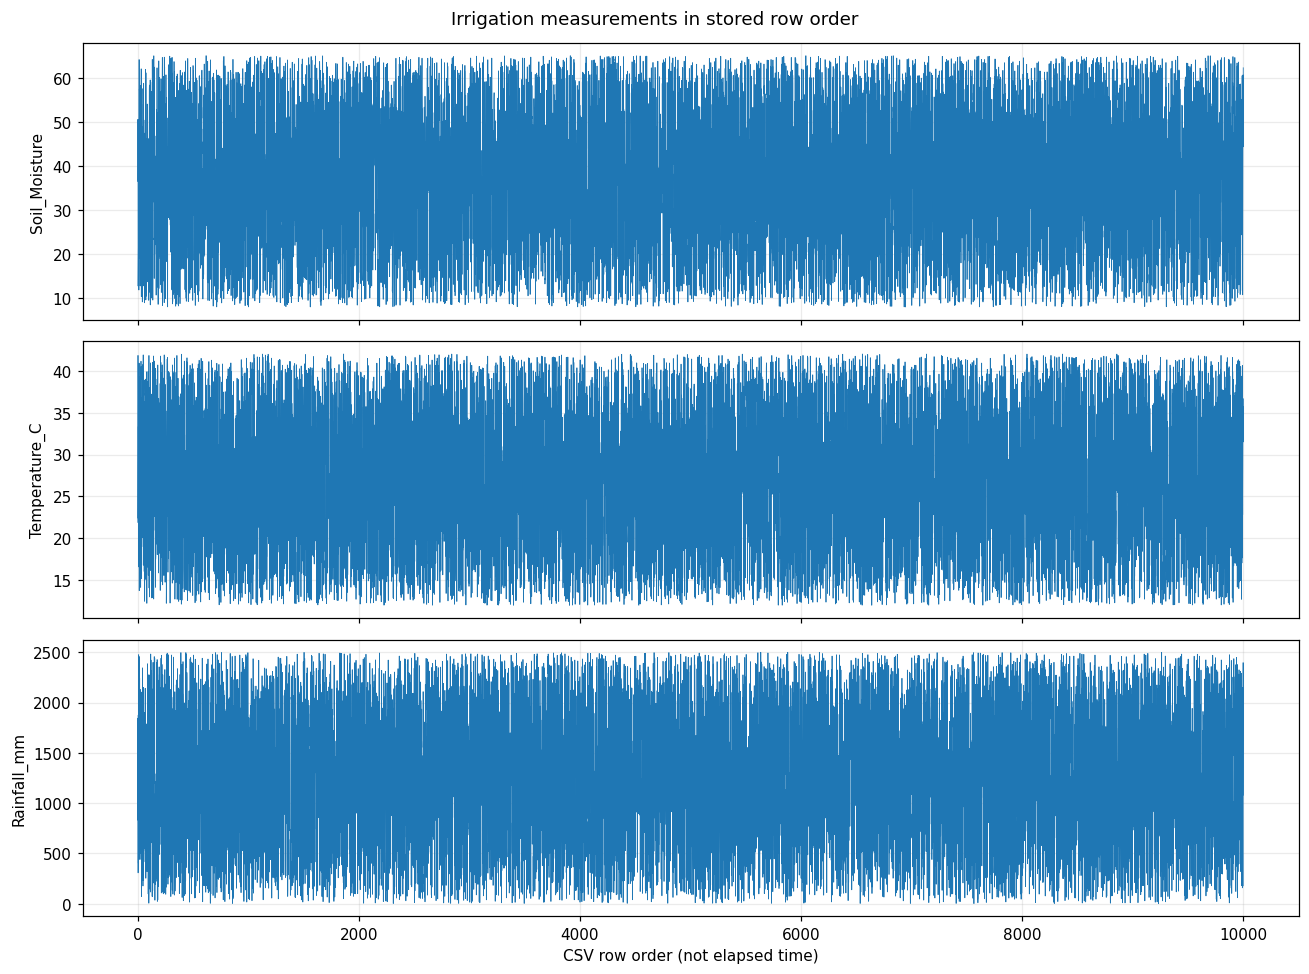

In [2]:
sensor_cols = ['Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Wind_Speed_kmh']
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, col in zip(axes, ['Soil_Moisture', 'Temperature_C', 'Rainfall_mm']):
    ax.plot(df['Observation_Order'], df[col], linewidth=0.5)
    ax.set_ylabel(col)
    ax.grid(alpha=0.25)
axes[-1].set_xlabel('CSV row order (not elapsed time)')
fig.suptitle('Irrigation measurements in stored row order')
plt.tight_layout()
plt.show()

variation = pd.DataFrame({
    'mean': df[sensor_cols].mean(),
    'std': df[sensor_cols].std(),
})
variation['coefficient_of_variation'] = variation['std'] / variation['mean'].abs()
print('Variation comparison (standard deviation / absolute mean):')
print(variation.sort_values('coefficient_of_variation', ascending=False).round(4).to_string())


## 7–8. Moving average and rolling standard deviation

Use a 100-row window for an illustrative smoothing exercise. It is **100 records**, not 100 minutes or days. Rolling measures must not be used for a maintenance claim without an actual timestamp and equipment identity.


First and last valid 100-row averages: 33.642 36.502
Overall soil moisture mean: 36.969


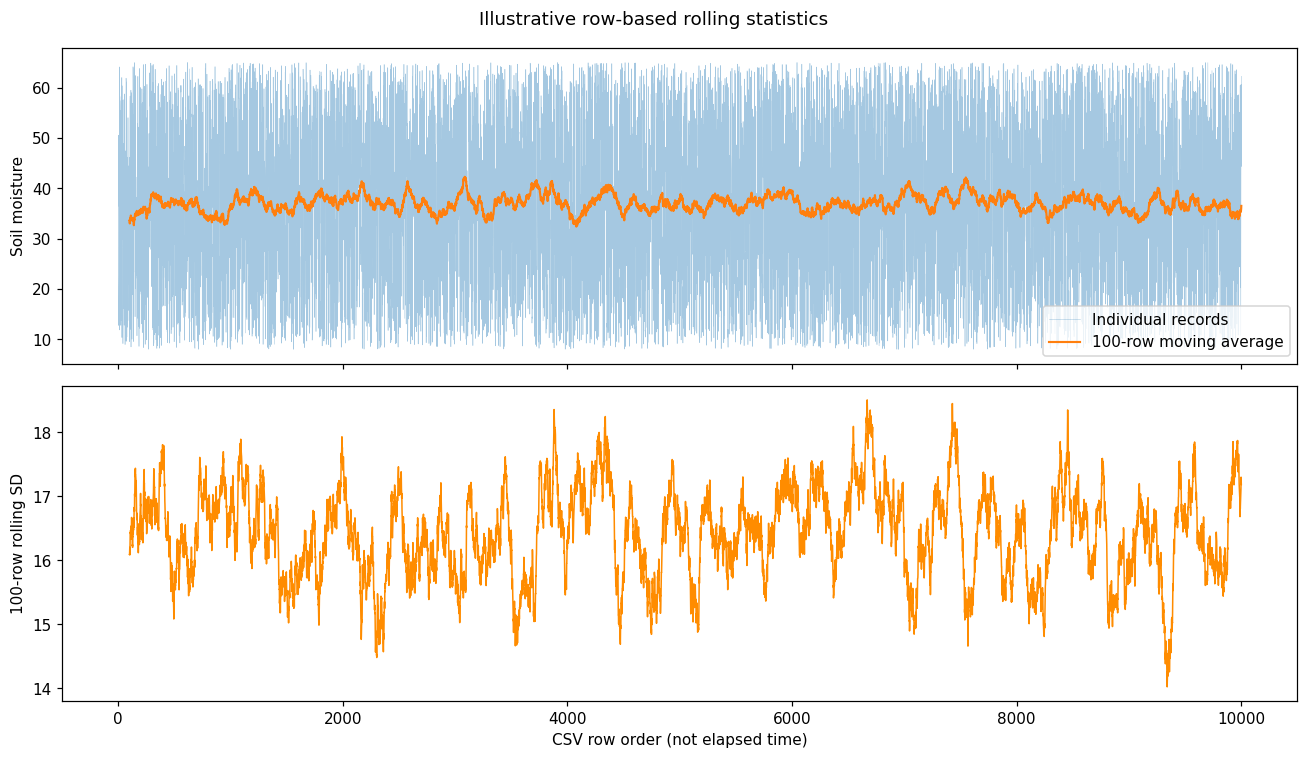

In [3]:
window = 100
series = df['Soil_Moisture']
df['Soil_Moisture_RowMA100'] = series.rolling(window, min_periods=window).mean()
df['Soil_Moisture_RowSD100'] = series.rolling(window, min_periods=window).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(df['Observation_Order'], series, linewidth=0.35, alpha=0.4, label='Individual records')
axes[0].plot(df['Observation_Order'], df['Soil_Moisture_RowMA100'], linewidth=1.4, label='100-row moving average')
axes[0].set_ylabel('Soil moisture')
axes[0].legend()
axes[1].plot(df['Observation_Order'], df['Soil_Moisture_RowSD100'], color='darkorange', linewidth=1)
axes[1].set_ylabel('100-row rolling SD')
axes[1].set_xlabel('CSV row order (not elapsed time)')
fig.suptitle('Illustrative row-based rolling statistics')
plt.tight_layout()
plt.show()
print('First and last valid 100-row averages:',
      round(df['Soil_Moisture_RowMA100'].dropna().iloc[0], 3),
      round(df['Soil_Moisture_RowMA100'].dropna().iloc[-1], 3))
print('Overall soil moisture mean:', round(series.mean(), 3))


**Inference:** A rolling average smooths row-to-row noise, but changes here cannot be interpreted as change over time because the CSV contains no clock or repeated equipment ID.


## 9. Flag statistical outliers in measured fields

For each of the five measured columns, flag values outside the conventional 1.5 × interquartile range fences. A row is marked if *any* one of these columns is flagged. This is an exploratory outlier definition, **not a labeled fault or sensor failure**.


In [4]:
q1 = df[sensor_cols].quantile(0.25)
q3 = df[sensor_cols].quantile(0.75)
iqr = q3 - q1
outlier_by_column = df[sensor_cols].lt(q1 - 1.5 * iqr) | df[sensor_cols].gt(q3 + 1.5 * iqr)
df['IQR_Outlier'] = outlier_by_column.any(axis=1)
anomaly_count = int(df['IQR_Outlier'].sum())
anomaly_pct = 100 * df['IQR_Outlier'].mean()
print('Outliers by measured column:')
print(outlier_by_column.sum().to_string())
print(f'Rows flagged: {anomaly_count}/{len(df)} ({anomaly_pct:.2f}%)')


Outliers by measured column:
Soil_Moisture     0
Temperature_C     0
Humidity          0
Rainfall_mm       0
Wind_Speed_kmh    0
Rows flagged: 0/10000 (0.00%)


## 10. Construct illustrative row-lag features

This demonstrates `shift()` and `diff()` as requested in the handout. Since consecutive rows may refer to unrelated fields, these columns are **excluded from the classifier**. In a timestamped, per-field dataset, these would instead be computed within each field after chronological sorting.


In [5]:
df['Soil_Moisture_PreviousRow'] = df['Soil_Moisture'].shift(1)
df['Soil_Moisture_RowChange'] = df['Soil_Moisture'].diff()
df['Temperature_C_PreviousRow'] = df['Temperature_C'].shift(1)
print(df[['Observation_Order', 'Soil_Moisture', 'Soil_Moisture_PreviousRow',
          'Soil_Moisture_RowChange', 'Temperature_C_PreviousRow']].head(7).to_string(index=False))


 Observation_Order  Soil_Moisture  Soil_Moisture_PreviousRow  Soil_Moisture_RowChange  Temperature_C_PreviousRow
                 1          36.48                        NaN                      NaN                        NaN
                 2          50.56                      36.48                    14.08                      21.90
                 3          40.07                      50.56                   -10.49                      36.50
                 4          12.75                      40.07                   -27.32                      41.83
                 5          18.58                      12.75                     5.83                      37.22
                 6          20.50                      18.58                     1.92                      22.38
                 7          22.70                      20.50                     2.20                      33.34


## 11–12. Prepare the irrigation classification data and split it

The target is `Irrigation_Need` (Low/Medium/High). Exclude the artificial index, all row-based features, and the exploratory outlier flag. The last 20% of rows are held out to follow the handout's ordered-split structure. Since these rows are not verified chronological observations, this is **an ordered holdout**, not a time-series backtest.


In [6]:
target = 'Irrigation_Need'
exclude = {target, 'Observation_Order', 'Soil_Moisture_RowMA100',
           'Soil_Moisture_RowSD100', 'Soil_Moisture_PreviousRow',
           'Soil_Moisture_RowChange', 'Temperature_C_PreviousRow', 'IQR_Outlier'}
feature_cols = [c for c in df.columns if c not in exclude]
X = df[feature_cols]
y = df[target]
cutoff = int(len(df) * 0.8)
X_train, X_test = X.iloc[:cutoff], X.iloc[cutoff:]
y_train, y_test = y.iloc[:cutoff], y.iloc[cutoff:]
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()
print('Train/test sizes:', len(X_train), len(X_test))
print('Train labels:', y_train.value_counts().to_dict())
print('Test labels:', y_test.value_counts().to_dict())
print('Majority-class test accuracy:', round((y_test == y_train.mode().iloc[0]).mean(), 4))


Train/test sizes: 8000 2000
Train labels: {'Low': 4674, 'Medium': 3038, 'High': 288}
Test labels: {'Low': 1190, 'Medium': 762, 'High': 48}
Majority-class test accuracy: 0.595


## 13. Train a classification model

Preprocessing is fitted only on training rows. Missing-value imputers are included so the pipeline remains usable if later field records contain gaps. One-hot encoding handles the nominal field descriptors.


In [7]:
preprocess = ColumnTransformer([
    ('numeric', SimpleImputer(strategy='median'), numeric_cols),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_cols),
])
model = Pipeline([
    ('preprocess', preprocess),
    ('classifier', RandomForestClassifier(n_estimators=120, min_samples_leaf=2,
                                          class_weight='balanced_subsample', random_state=42,
                                          n_jobs=-1)),
])
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('Model fitted to original irrigation fields; target = Irrigation_Need.')


Model fitted to original irrigation fields; target = Irrigation_Need.


## 14. Evaluate the model

Accuracy alone can hide errors on the rare `High` class. Report macro F1, balanced accuracy, a per-class report, and a confusion matrix alongside the majority-class baseline.


In [8]:
labels = ['Low', 'Medium', 'High']
accuracy = accuracy_score(y_test, pred)
macro_f1 = f1_score(y_test, pred, labels=labels, average='macro', zero_division=0)
balanced_acc = balanced_accuracy_score(y_test, pred)
baseline_accuracy = (y_test == y_train.mode().iloc[0]).mean()
print(f'Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)')
print(f'Majority-class baseline accuracy: {baseline_accuracy:.4f}')
print(f'Balanced accuracy: {balanced_acc:.4f}')
print(f'Macro F1: {macro_f1:.4f}')
print('\nClassification report:')
print(classification_report(y_test, pred, labels=labels, zero_division=0))
print('Confusion matrix (rows=true, columns=predicted; Low, Medium, High):')
print(pd.DataFrame(confusion_matrix(y_test, pred, labels=labels), index=labels, columns=labels).to_string())


Accuracy: 0.9830 (98.30%)
Majority-class baseline accuracy: 0.5950
Balanced accuracy: 0.8880
Macro F1: 0.9282

Classification report:
              precision    recall  f1-score   support

         Low       0.99      1.00      0.99      1190
      Medium       0.98      0.98      0.98       762
        High       1.00      0.69      0.81        48

    accuracy                           0.98      2000
   macro avg       0.99      0.89      0.93      2000
weighted avg       0.98      0.98      0.98      2000

Confusion matrix (rows=true, columns=predicted; Low, Medium, High):
         Low  Medium  High
Low     1187       3     0
Medium    16     746     0
High       0      15    33


## 15. Interpret the input features

Permutation importance measures the drop in held-out macro F1 when one *original* input column is shuffled. This is more interpretable for mixed numerical/categorical inputs than reporting dozens of one-hot columns. Importances are predictive associations on this split, not causal effects.


In [9]:
importance = permutation_importance(model, X_test, y_test, scoring='f1_macro',
                                    n_repeats=3, random_state=42, n_jobs=1)
importance_table = pd.DataFrame({
    'feature': feature_cols,
    'macro_F1_drop': importance.importances_mean,
    'repeat_sd': importance.importances_std,
}).sort_values('macro_F1_drop', ascending=False)
print(importance_table.round(4).to_string(index=False))


                feature  macro_F1_drop  repeat_sd
          Soil_Moisture         0.3324     0.0058
      Crop_Growth_Stage         0.3006     0.0261
         Wind_Speed_kmh         0.2218     0.0123
          Temperature_C         0.1913     0.0058
          Mulching_Used         0.1685     0.0177
            Rainfall_mm         0.1407     0.0077
 Previous_Irrigation_mm         0.0158     0.0046
           Water_Source         0.0138     0.0021
Electrical_Conductivity         0.0099     0.0042
              Crop_Type         0.0093     0.0044
                 Region         0.0079     0.0066
        Irrigation_Type         0.0058     0.0028
         Organic_Carbon         0.0053     0.0043
                Soil_pH         0.0053     0.0070
              Soil_Type         0.0047     0.0044
     Field_Area_hectare         0.0046     0.0049
         Sunlight_Hours         0.0046     0.0004
               Humidity         0.0019     0.0026
                 Season         0.0006     0.0045


## Students should answer

The answers below are generated from this notebook's calculations. The wording keeps the missing timestamp, vibration, and fault data explicit.


In [10]:
strongest = variation['coefficient_of_variation'].idxmax()
strongest_cv = variation.loc[strongest, 'coefficient_of_variation']
top_features = ', '.join(importance_table.head(3)['feature'])
top_measured = ', '.join(importance_table.set_index('feature').loc[sensor_cols]
                         .sort_values('macro_F1_drop', ascending=False).head(3).index)
print(f'1. Among the five measured fields compared, {strongest} has the largest relative spread '
      f'(coefficient of variation {strongest_cv:.3f}). This is variation across records, '
      'not proven temporal variation.')
print('2. Cannot determine whether abnormal vibration preceded failures: neither vibration, '
      'failure events, nor timestamps appear in this CSV.')
print('3. The 100-row moving average smooths soil-moisture values, but it cannot reveal a '
      'validated time trend. Consecutive rows are not established as successive readings.')
print(f'4. {anomaly_pct:.2f}% of rows ({anomaly_count}/{len(df)}) were flagged by the specified '
      '1.5×IQR rule on the five measured fields. This is not a failure rate.')
print(f'5. Equipment-failure accuracy is unavailable. The irrigation-need classifier achieved '
      f'{accuracy * 100:.2f}% accuracy, {balanced_acc:.3f} balanced accuracy, and '
      f'{macro_f1:.3f} macro F1 on the last 20% of CSV rows.')
print(f'6. The top measured features by held-out permutation macro-F1 drop were: {top_measured}. '
      f'Across all fields, the top three were: {top_features}. These contribute to irrigation-need '
      'classification, not demonstrated failure prediction.')


1. Among the five measured fields compared, Rainfall_mm has the largest relative spread (coefficient of variation 0.571). This is variation across records, not proven temporal variation.
2. Cannot determine whether abnormal vibration preceded failures: neither vibration, failure events, nor timestamps appear in this CSV.
3. The 100-row moving average smooths soil-moisture values, but it cannot reveal a validated time trend. Consecutive rows are not established as successive readings.
4. 0.00% of rows (0/10000) were flagged by the specified 1.5×IQR rule on the five measured fields. This is not a failure rate.
5. Equipment-failure accuracy is unavailable. The irrigation-need classifier achieved 98.30% accuracy, 0.888 balanced accuracy, and 0.928 macro F1 on the last 20% of CSV rows.
6. The top measured features by held-out permutation macro-F1 drop were: Soil_Moisture, Wind_Speed_kmh, Temperature_C. Across all fields, the top three were: Soil_Moisture, Crop_Growth_Stage, Wind_Speed_kmh. 

## Post-lab questions

1. **Time-series data:** Measurements indexed by actual observation time, usually ordered and often repeated for the same device.
2. **Why timestamps matter:** They establish sequence, elapsed intervals, rates of change, and valid windows before a known event.
3. **Tabular versus time series:** Ordinary rows may be independent records; a time series carries temporal dependence and ordering. This CSV is tabular.
4. **Moving average:** The mean of a sliding window of adjacent observations.
5. **Why useful:** It can smooth noise and expose slower change when observations really are sequential in time.
6. **Anomaly:** A reading or pattern unusually different from an explicit normal baseline; an outlier is not automatically a fault.
7. **Vibration and failure:** Rising amplitude or changed frequency content can indicate wear, imbalance, or looseness, after accounting for speed/load and validated baselines.
8. **Rolling standard deviation:** It measures local variability and can show changing process noise or instability.
9. **Why avoid random shuffling:** With real time series, training on future records can leak information into evaluation of earlier predictions.
10. **Forecasting versus classification:** Forecasting predicts a future numerical value or trajectory; classification assigns a discrete class such as fault/no fault.
11. **`diff()`:** It subtracts the preceding value to estimate change between adjacent observations; interpretation needs genuine ordering.
12. **Failure metrics:** Precision, recall, F1, balanced accuracy, confusion matrix, and sometimes PR-AUC; choose metrics for the cost of missed faults and false alarms.
13. **Precision, recall, F1:** Precision is true positives among predicted positives; recall is true positives among actual positives; F1 is their harmonic mean.
14. **Class imbalance:** A model can appear accurate by predicting only the majority class while missing rare failures.
15. **Predictive maintenance:** Valid timestamped per-machine histories can expose degradation, support early alerts, and inform maintenance timing after prospective validation.


## Final result and limitations

This notebook completes the available data inspection, row-order plots, rolling calculations, outlier screen, feature engineering demonstration, and an evaluated **irrigation need** model. The source CSV cannot support a genuine robotic sensor failure prediction, pre-failure vibration analysis, or time-series validation. For those conclusions, collect timestamps, equipment/field IDs, vibration telemetry, and verified failure-event labels.

**Dataset reference:** [Local irrigation dataset](irrigation_prediction.csv).  
**Method reference:** Supplied `EXP4 DS.pdf` and `DS_EXP4.ipynb`.
